# MPC-CVMM
This uses the official CasADi/IPOPT `CollisionAvoidMPC` implementation with `hum_model=cvmm`. The optimizer chooses a sequence of unicycle controls over the horizon while humans retain their currently observed velocity. The simulator humans still move with their configured policy, so prediction error remains real.

In [1]:
from pathlib import Path
import sys
here = Path.cwd().resolve()
ROOT = next(p for p in (here, *here.parents) if (p / 'experiments/crowd_navigation/navigation.py').exists())
EXP = ROOT / 'experiments/crowd_navigation'
sys.path.insert(0, str(EXP))
from navigation import dependency_report, plot_episode, run_navigation_suite, summarize
dependency_report('mpc_cvmm')

method               mpc_cvmm
rvo2                     True
casadi                   True
acados_template          True
ACADOS_SOURCE_DIR       False
checkpoint               True
dtype: object

## One episode
The first call constructs the symbolic nonlinear program. Later control steps warm-start from the previous solution.



                                 	 HSL solvers are not loading properly. MA57 linear solver not available for IPOPT, using default instead.
                                 	 This is untested and may be slower and less stable. Please install HSL libraries.


                                 	=== [CAMPC] WARNING =====================================================================================


[mpc_cvmm] hallway_bottleneck case=0 success=True collisions=0 time=2.75s


,test_case,robot_policy,human_policy,scenario,success,timeout,navigation_time_s,steps,collision_steps,wall_collision_steps,...,path_length_m,path_efficiency,cumulative_reward,mean_policy_time_ms,max_policy_time_ms,mean_abs_linear_accel_mps2,mean_abs_angular_rate_radps,mean_abs_angular_accel_radps2,method,human_count
0,0,CollisionAvoidMPC,ORCAPlus,hallway_bottleneck,True,False,2.75,11,0,0,...,1.825,0.986319,1.0,20.474663,112.52275,0.33,0.435238,1.538881,mpc_cvmm,3


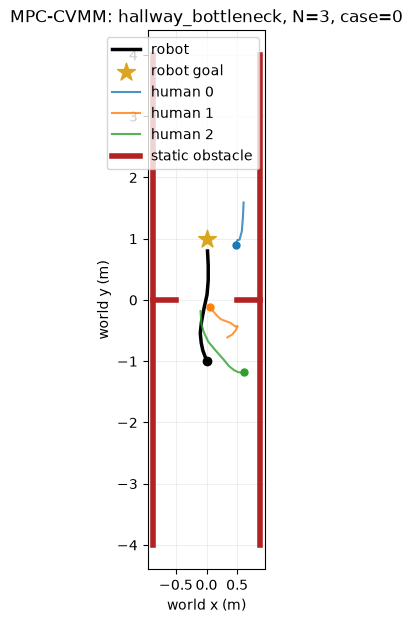

In [2]:
SCENARIO = 'hallway_bottleneck'
HUMAN_COUNT = 3
CASE = 0
one, episodes = run_navigation_suite('mpc_cvmm', cases=[CASE], scenario=SCENARIO, human_count=HUMAN_COUNT, device='auto')
display(one)
plot_episode(episodes[CASE], title=f'MPC-CVMM: {SCENARIO}, N={HUMAN_COUNT}, case={CASE}');

## Small suite
CasADi rebuilds this controller at each reset in the released implementation, so begin with five cases before scaling up.

In [3]:
results, _ = run_navigation_suite('mpc_cvmm', cases=range(5), scenario=SCENARIO, human_count=HUMAN_COUNT, device='auto', output_dir=EXP/'outputs/policy_benchmark')
summarize(results)



                                 	 HSL solvers are not loading properly. MA57 linear solver not available for IPOPT, using default instead.
                                 	 This is untested and may be slower and less stable. Please install HSL libraries.


                                 	=== [CAMPC] WARNING =====================================================================================


[mpc_cvmm] hallway_bottleneck case=0 success=True collisions=0 time=2.75s




                                 	 HSL solvers are not loading properly. MA57 linear solver not available for IPOPT, using default instead.
                                 	 This is untested and may be slower and less stable. Please install HSL libraries.


                                 	=== [CAMPC] WARNING =====================================================================================


[mpc_cvmm] hallway_bottleneck case=1 success=True collisions=3 time=3.50s




                                 	 HSL solvers are not loading properly. MA57 linear solver not available for IPOPT, using default instead.
                                 	 This is untested and may be slower and less stable. Please install HSL libraries.


                                 	=== [CAMPC] WARNING =====================================================================================


...



                                 	 HSL solvers are not loading properly. MA57 linear solver not available for IPOPT, using default instead.
                                 	 This is untested and may be slower and less stable. Please install HSL libraries.


                                 	=== [CAMPC] WARNING =====================================================================================


[mpc_cvmm] hallway_bottleneck case=3 success=True collisions=0 time=2.75s




                                 	 HSL solvers are not loading properly. MA57 linear solver not available for IPOPT, using default instead.
                                 	 This is untested and may be slower and less stable. Please install HSL libraries.


                                 	=== [CAMPC] WARNING =====================================================================================


[mpc_cvmm] hallway_bottleneck case=4 success=True collisions=0 time=2.25s


episodes                              5.000000
success_rate                          1.000000
timeout_rate                          0.000000
episodes_with_collision_rate          0.200000
episodes_with_wall_collision_rate     0.000000
mean_navigation_time_s                2.800000
mean_minimum_clearance_m              0.034271
mean_path_efficiency                  0.985797
mean_policy_time_ms                  20.598967
mean_abs_linear_accel_mps2            0.399479
mean_abs_angular_rate_radps           0.361151
mean_abs_angular_accel_radps2         1.779348
dtype: float64